In [55]:
image_set = "h&m"
text_set = "opencharacter"
mode = "test"

In [56]:
from sklearn.metrics.pairwise import cosine_similarity
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import os
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [57]:
combined_set = image_set + "+" + text_set

In [58]:
# Load model and processor
# model = CLIPModel.from_pretrained("patrickjohncyh/fashion-clip")
# processor = CLIPProcessor.from_pretrained("patrickjohncyh/fashion-clip")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

In [59]:
if mode == "test":
    with open(f"../generate_test_set/{combined_set}/test_indices.json", "r") as f:
        test_indices = json.load(f)
    with open(f'../data_preparation/{image_set}/images_test.pkl', 'rb') as f:
        sampled_images = pickle.load(f)
    with open(f'../data_preparation/{text_set}/test_personas.json', 'r') as f:
        test_personas = json.load(f)[:len(test_indices)]
if mode == "val":
    with open(f"../generate_test_set/{combined_set}/val_indices.json", "r") as f:
        test_indices = json.load(f)
    with open(f'../data_preparation/{image_set}/images_val.pkl', 'rb') as f:
        sampled_images = pickle.load(f)
    with open(f'../data_preparation/{text_set}/validation_personas.json', 'r') as f:
        test_personas = json.load(f)[:len(test_indices)]

In [60]:
len(test_personas), len(sampled_images), len(test_indices)

(50, 4096, 50)

In [61]:
text_inputs = processor(text=test_personas, return_tensors="pt", padding=True, truncation=True, max_length=77)
text_features = model.get_text_features(**text_inputs)

In [62]:
image_embeddings = []

for image in tqdm(sampled_images):
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        image_features = model.get_image_features(**inputs)
    image_embeddings.append(image_features)

  0%|          | 0/4096 [00:00<?, ?it/s]

In [63]:
image_embeddings_tensor = torch.cat(image_embeddings)

In [64]:
rank_list = []
K = []
for i in range(len(text_features)):
    scores = cosine_similarity(
        image_embeddings_tensor.detach().cpu().numpy(),
        text_features[i].unsqueeze(0).detach().cpu().numpy()
    )
    sorted_indices = np.argsort(scores, axis=0).squeeze()[::-1]
    K.append(sorted_indices.tolist())
    n = sorted_indices.tolist().index(test_indices[i])
    rank_list.append(n)

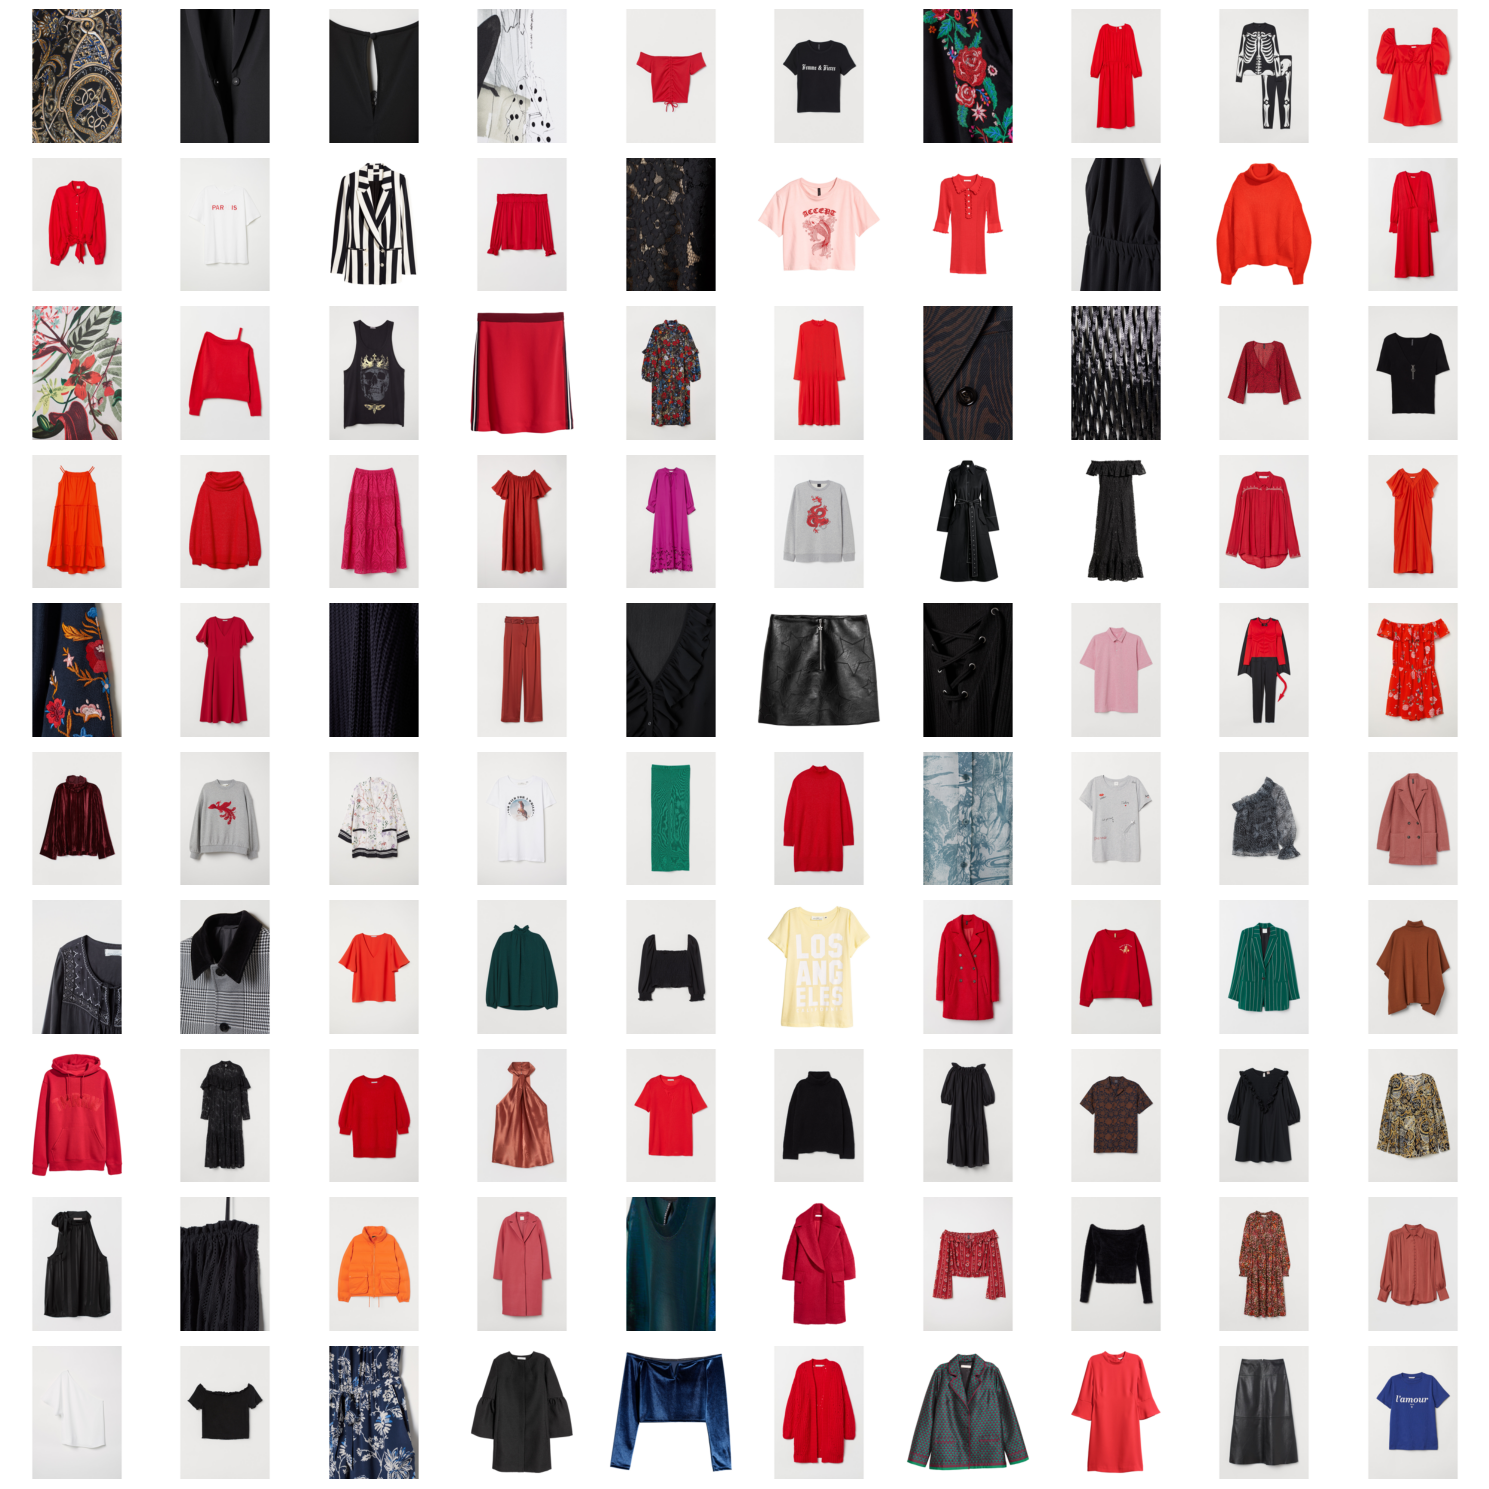

In [65]:
import matplotlib.pyplot as plt

# Get the first 100 indices from K[1]
indices = K[0][:100]

# Create a grid for displaying images
rows, cols = 10, 10  # 10x10 grid
fig, axes = plt.subplots(rows, cols, figsize=(15, 15))

for i, ax in enumerate(axes.flat):
    img_index = indices[i]
    ax.imshow(sampled_images[img_index], cmap='gray')  # Remove cmap='gray' if images are RGB
    ax.axis('off')

plt.tight_layout()
plt.show()


(array([ 3.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  3.,  2.,
         4.,  3.,  1.,  2.,  2.,  5., 23.]),
 array([0.01855469, 0.06762695, 0.11669922, 0.16577148, 0.21484375,
        0.26391602, 0.31298828, 0.36206055, 0.41113281, 0.46020508,
        0.50927734, 0.55834961, 0.60742188, 0.65649414, 0.70556641,
        0.75463867, 0.80371094, 0.8527832 , 0.90185547, 0.95092773,
        1.        ]),
 <BarContainer object of 20 artists>)

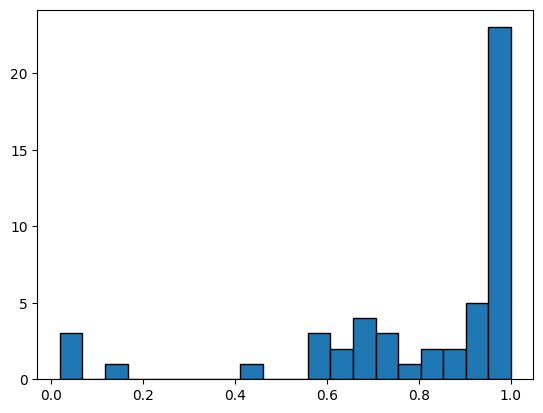

In [66]:
plt.hist(1-np.array(rank_list)/len(image_embeddings_tensor), bins=20, edgecolor='black')

In [67]:
from tqdm.notebook import tqdm

top_5 = 0
top_20 = 0
top_100 = 0
top_500 = 0

for i in tqdm(range(len(rank_list))):
    if rank_list[i] < 5:
        top_5 += 1/len(rank_list)
    if rank_list[i] < 20:
        top_20 += 1/len(rank_list)
    if rank_list[i] < 100:
        top_100 += 1/len(rank_list)
    if rank_list[i] < 500:
        top_500 += 1/len(rank_list)

  0%|          | 0/50 [00:00<?, ?it/s]

In [68]:
len(image_embeddings_tensor)

4096

In [69]:
len(rank_list)

50

In [70]:
median_rank = 1-np.median(rank_list)/len(image_embeddings_tensor)
mean_rank = 1-np.mean(rank_list)/len(image_embeddings_tensor)

In [71]:
print("Top 5:", top_5, "Top 20:", top_20, "Top 100:", top_100, "Top 500:", top_500)
print("Median rank", 1-np.median(rank_list)/len(image_embeddings_tensor))
print("Mean rank", 1-np.mean(rank_list)/len(image_embeddings_tensor))
print("Top quartile", 1-np.percentile(rank_list, 25)/len(image_embeddings_tensor))

Top 5: 0.04 Top 20: 0.08 Top 100: 0.27999999999999997 Top 500: 0.5800000000000002
Median rank 0.925048828125
Mean rank 0.7989794921875
Top quartile 0.9847412109375


In [72]:
from random import randint

37
As a local restaurant owner who's been operating in Darlington for over 15 years.
903


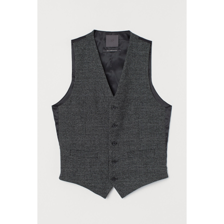

In [73]:
n = randint(0, len(test_personas) - 1)
print(n)
print(test_personas[n])
print(test_indices[n])
sampled_images[test_indices[n]]

In [74]:
sorted_indices

array([1102, 3254, 3654, ...,  907,  143, 2442], dtype=int64)

a financial analyst who is skeptical about celebrity wealth estimations


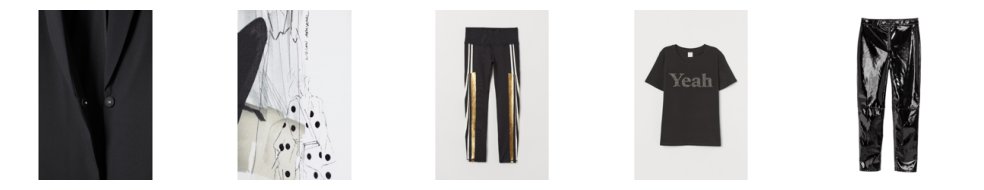

In [77]:
n = 1
print(test_personas[n])

stop_step = 0

img_list = [sampled_images[k] for k in K[n]]

num_images = 5
cols = 10  # images per row
rows = int(np.ceil(num_images / cols))

plt.figure(figsize=(cols * 2, rows * 2))  # adjust size as needed

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img_list[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [76]:
with open(f'scores.json', 'r') as f:
    scores = json.load(f)
scores[image_set + "+" + text_set] = [median_rank, mean_rank, top_5, top_20, top_100, top_500]
with open(f'scores.json', 'w') as f:
    json.dump(scores, f)